**SCENARIOS**

SCENARIO 1

Simple analogy for better understading


**BASE SETUP**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv")

# Set timestamp
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp")


cols = [
    "DE_load_actual_entsoe_transparency",
    "FR_load_actual_entsoe_transparency",
    "BE_load_actual_entsoe_transparency",
    "DE_wind_generation_actual",
    "DE_solar_generation_actual",
    "FR_solar_generation_actual",
    "BE_solar_generation_actual"
]

df_model = df[cols].copy().dropna()

# Build base demand and generation
df_model["total_demand"] = (
    df_model["DE_load_actual_entsoe_transparency"] +
    df_model["FR_load_actual_entsoe_transparency"] +
    df_model["BE_load_actual_entsoe_transparency"]
)

df_model["total_generation"] = (
    df_model["DE_wind_generation_actual"] +
    df_model["DE_solar_generation_actual"] +
    df_model["FR_solar_generation_actual"] +
    df_model["BE_solar_generation_actual"]
)

df_model["other_generation"] = 50000  # adjust if needed
df_model["total_generation"] = df_model["total_generation"] + df_model["other_generation"]

# Base grid balance
df_model["grid_balance"] = df_model["total_generation"] - df_model["total_demand"]

print(df_model.head())

                           DE_load_actual_entsoe_transparency  \
utc_timestamp                                                   
2015-01-01 08:00:00+00:00                             42963.0   
2015-01-01 09:00:00+00:00                             45088.0   
2015-01-01 10:00:00+00:00                             47013.0   
2015-01-01 11:00:00+00:00                             48159.0   
2015-01-01 12:00:00+00:00                             47164.0   

                           FR_load_actual_entsoe_transparency  \
utc_timestamp                                                   
2015-01-01 08:00:00+00:00                             64277.0   
2015-01-01 09:00:00+00:00                             65100.0   
2015-01-01 10:00:00+00:00                             65875.0   
2015-01-01 11:00:00+00:00                             67460.0   
2015-01-01 12:00:00+00:00                             65706.0   

                           BE_load_actual_entsoe_transparency  \
utc_timestamp          

**SCENARIO 1**

DEMAND SURGE

Heatwave → more air conditioning → demand ↑

In [4]:
df_scenario1 = df_model.copy()

# Increase total demand by 10%
df_scenario1["total_demand"] = df_scenario1["total_demand"] * 1.10

# Recalculate balance
df_scenario1["grid_balance"] = df_scenario1["total_generation"] - df_scenario1["total_demand"]

What we do:
Increase electricity demand by 10%.

Why:
Simulates events like heatwaves or higher consumption.

What we test:
Can the grid handle higher demand?

Expected result:
More shortages, more stress on the grid.

**SCENARIO 2**

No wind day → wind turbines produce less

In [5]:
df_scenario2 = df_model.copy()

# Reduce German wind generation by 30%
df_scenario2["DE_wind_generation_actual"] = df_scenario2["DE_wind_generation_actual"] * 0.70

# Recalculate generation
df_scenario2["total_generation"] = (
    df_scenario2["DE_wind_generation_actual"] +
    df_scenario2["DE_solar_generation_actual"] +
    df_scenario2["FR_solar_generation_actual"] +
    df_scenario2["BE_solar_generation_actual"] +
    df_scenario2["other_generation"]
)

# Recalculate balance
df_scenario2["grid_balance"] = df_scenario2["total_generation"] - df_scenario2["total_demand"]

What we do:
Reduce wind generation in Germany by 30%.

Why:
Simulates low-wind conditions where turbines produce less electricity.

What we test:
How dependent the grid is on wind energy.

**SCENARIO 3**

More solar panels → higher production

In [6]:
df_scenario3 = df_model.copy()

# Increase German solar generation by 20%
df_scenario3["DE_solar_generation_actual"] = df_scenario3["DE_solar_generation_actual"] * 1.20

# Recalculate generation
df_scenario3["total_generation"] = (
    df_scenario3["DE_wind_generation_actual"] +
    df_scenario3["DE_solar_generation_actual"] +
    df_scenario3["FR_solar_generation_actual"] +
    df_scenario3["BE_solar_generation_actual"] +
    df_scenario3["other_generation"]
)

# Recalculate balance
df_scenario3["grid_balance"] = df_scenario3["total_generation"] - df_scenario3["total_demand"]

What we do:
Increase solar generation in Germany by 20%.

Why:
Simulates expansion of solar energy (more panels, policy investment).

What we test:
If increasing renewable production improves grid stability.

Text(0.5, 0, 'Time')

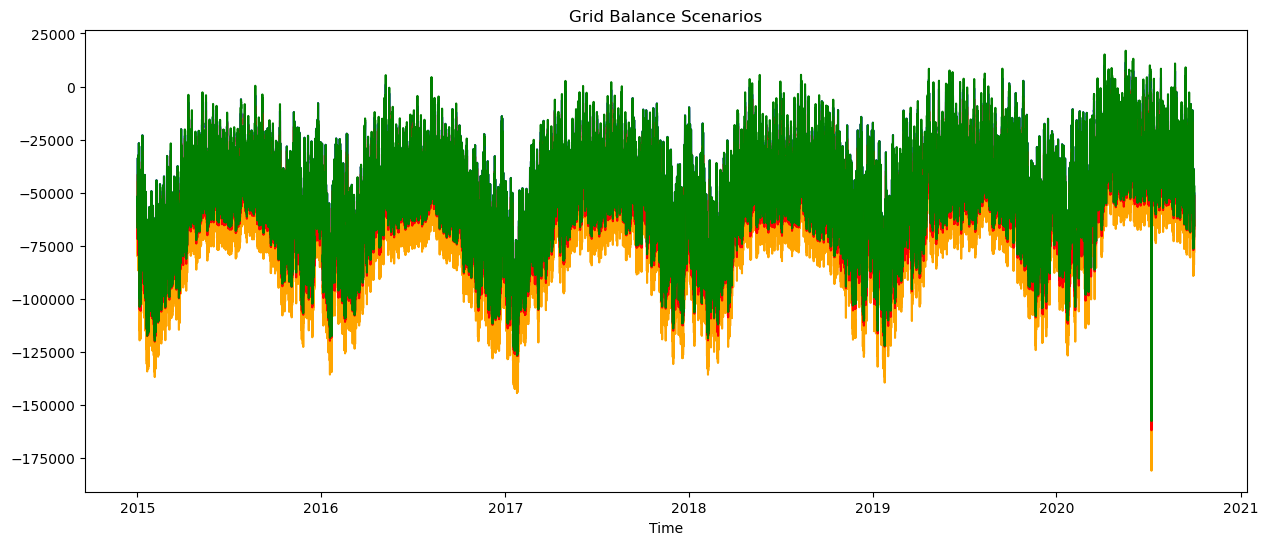

In [7]:
import matplotlib.dates as mdates
plt.figure(figsize=(15, 6))
plt.plot(df_model.index, df_model["grid_balance"], label="Base", color="blue")
plt.plot(df_scenario1.index, df_scenario1["grid_balance"], label="Demand +10%", color="orange")
plt.plot(df_scenario2.index, df_scenario2["grid_balance"], label="Wind -30%", color="red")
plt.plot(df_scenario3.index, df_scenario3["grid_balance"], label="Solar +20%", color="green")
plt.title("Grid Balance Scenarios")
plt.xlabel("Time")  

In [8]:
def shortage_rate(df_in):
    return (df_in["grid_balance"] < 0).mean() * 100

print("Base shortage rate:      ", round(shortage_rate(df_model), 2), "%")
print("Demand surge shortage:   ", round(shortage_rate(df_scenario1), 2), "%")
print("Wind drop shortage:      ", round(shortage_rate(df_scenario2), 2), "%")
print("Solar increase shortage: ", round(shortage_rate(df_scenario3), 2), "%")

Base shortage rate:       99.77 %
Demand surge shortage:    99.99 %
Wind drop shortage:       99.96 %
Solar increase shortage:  99.48 %


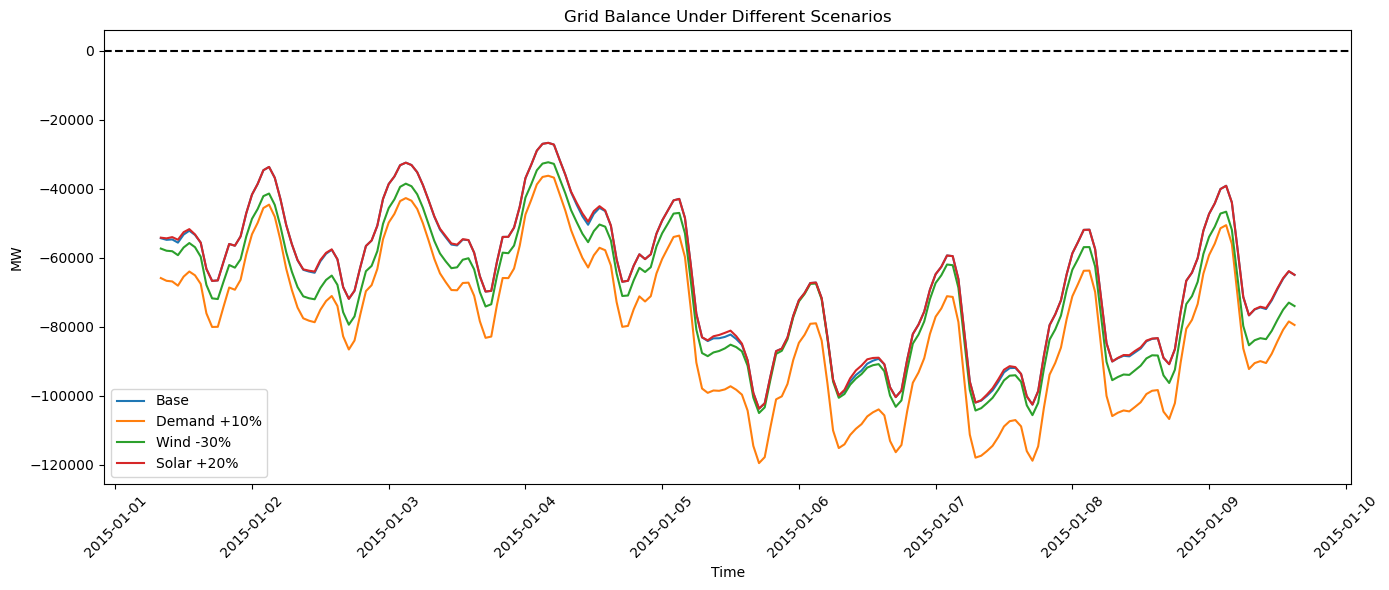

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(df_model.index[:200], df_model["grid_balance"].iloc[:200], label="Base")
plt.plot(df_scenario1.index[:200], df_scenario1["grid_balance"].iloc[:200], label="Demand +10%")
plt.plot(df_scenario2.index[:200], df_scenario2["grid_balance"].iloc[:200], label="Wind -30%")
plt.plot(df_scenario3.index[:200], df_scenario3["grid_balance"].iloc[:200], label="Solar +20%")

plt.axhline(0, color="black", linestyle="--")
plt.title("Grid Balance Under Different Scenarios")
plt.ylabel("MW")
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
scenario_results = pd.DataFrame({
    "Scenario": ["Base", "Demand +10%", "Wind -30%", "Solar +20%"],
    "Shortage Rate (%)": [
        shortage_rate(df_model),
        shortage_rate(df_scenario1),
        shortage_rate(df_scenario2),
        shortage_rate(df_scenario3)
    ],
    "Average Balance (MW)": [
        df_model["grid_balance"].mean(),
        df_scenario1["grid_balance"].mean(),
        df_scenario2["grid_balance"].mean(),
        df_scenario3["grid_balance"].mean()
    ]
})

print(scenario_results)

      Scenario  Shortage Rate (%)  Average Balance (MW)
0         Base          99.765155         -50907.454422
1  Demand +10%          99.990049         -62760.756950
2    Wind -30%          99.962186         -54373.675713
3   Solar +20%          99.484536         -49993.937629


The negative average balance indicates that the model does not include all energy sources,
such as nuclear or fossil fuels, leading to an underestimation of total generation.

Increasing solar capacity improves grid stability during daylight hours,
but does not fully solve evening demand peaks.


-Demand +10%: stress on the grid from heatwave, cold wave, or consumption spike

-Wind -30%: renewable supply shock

-Solar +20%: policy / infrastructure improvement scenario

-demand surge worsens the balance

-wind drop worsens the balance a lot

-solar increase improves daytime balance, but not all hours

`Weather changes`

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. BASELINE
# -----------------------------------------
scenario_df = df_model.copy()

# -----------------------------------------
# 2. SCENARIOS
# -----------------------------------------

# Scenario A: cloudy weather -> solar drops by 30%
scenario_df["solar_drop_generation"] = (
    scenario_df["DE_wind_generation_actual"] +
    scenario_df["DE_solar_generation_actual"] * 0.70 +
    scenario_df["FR_solar_generation_actual"] * 0.70 +
    scenario_df["BE_solar_generation_actual"] * 0.70 +
    scenario_df["other_generation"]
)

scenario_df["solar_drop_balance"] = (
    scenario_df["solar_drop_generation"] - scenario_df["total_demand"]
)

# Scenario B: low wind -> wind drops by 40%
scenario_df["wind_drop_generation"] = (
    scenario_df["DE_wind_generation_actual"] * 0.60 +
    scenario_df["DE_solar_generation_actual"] +
    scenario_df["FR_solar_generation_actual"] +
    scenario_df["BE_solar_generation_actual"] +
    scenario_df["other_generation"]
)

scenario_df["wind_drop_balance"] = (
    scenario_df["wind_drop_generation"] - scenario_df["total_demand"]
)

# Scenario C: cold wave -> demand rises by 10%
scenario_df["cold_wave_demand"] = scenario_df["total_demand"] * 1.10

scenario_df["cold_wave_balance"] = (
    scenario_df["total_generation"] - scenario_df["cold_wave_demand"]
)

# Scenario D: combined stress -> low wind + solar drop + demand increase
scenario_df["stress_generation"] = (
    scenario_df["DE_wind_generation_actual"] * 0.60 +
    scenario_df["DE_solar_generation_actual"] * 0.70 +
    scenario_df["FR_solar_generation_actual"] * 0.70 +
    scenario_df["BE_solar_generation_actual"] * 0.70 +
    scenario_df["other_generation"]
)

scenario_df["stress_demand"] = scenario_df["total_demand"] * 1.10

scenario_df["stress_balance"] = (
    scenario_df["stress_generation"] - scenario_df["stress_demand"]
)

# -----------------------------------------
# 3. COUNT RISK PERIODS
# -----------------------------------------
print("Base shortage periods:", (scenario_df["grid_balance"] < 0).sum())
print("Solar drop shortage periods:", (scenario_df["solar_drop_balance"] < 0).sum())
print("Wind drop shortage periods:", (scenario_df["wind_drop_balance"] < 0).sum())
print("Cold wave shortage periods:", (scenario_df["cold_wave_balance"] < 0).sum())
print("Combined stress shortage periods:", (scenario_df["stress_balance"] < 0).sum())

Base shortage periods: 50128
Solar drop shortage periods: 50229
Wind drop shortage periods: 50230
Cold wave shortage periods: 50241
Combined stress shortage periods: 50246


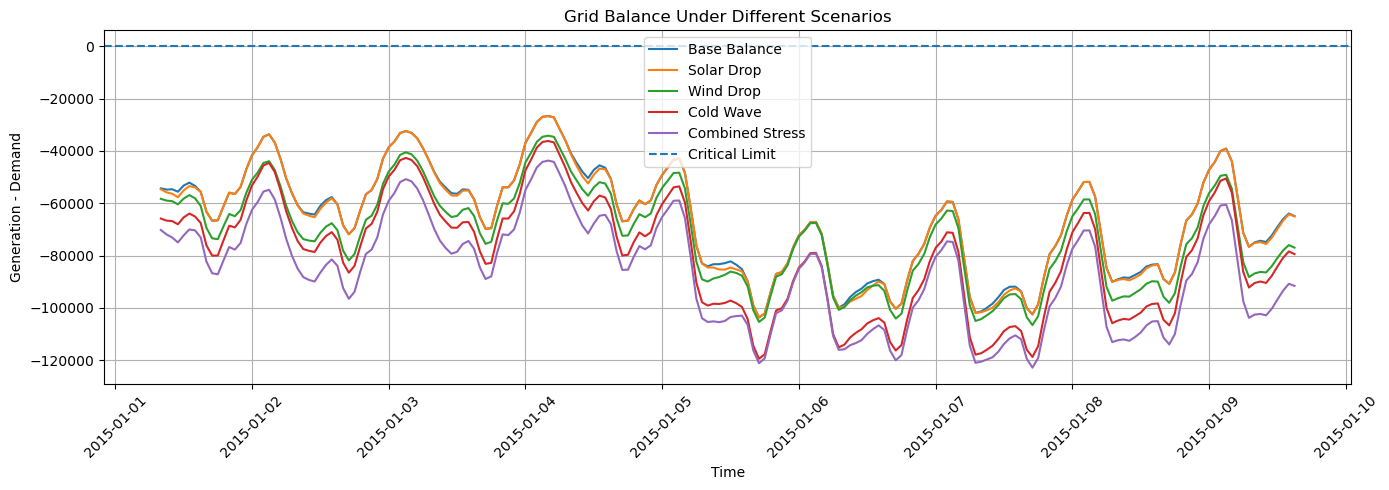

In [12]:
n = 200

plt.figure(figsize=(14, 5))
plt.plot(scenario_df.index[:n], scenario_df["grid_balance"].iloc[:n], label="Base Balance")
plt.plot(scenario_df.index[:n], scenario_df["solar_drop_balance"].iloc[:n], label="Solar Drop")
plt.plot(scenario_df.index[:n], scenario_df["wind_drop_balance"].iloc[:n], label="Wind Drop")
plt.plot(scenario_df.index[:n], scenario_df["cold_wave_balance"].iloc[:n], label="Cold Wave")
plt.plot(scenario_df.index[:n], scenario_df["stress_balance"].iloc[:n], label="Combined Stress")

plt.axhline(0, linestyle="--", label="Critical Limit")

plt.title("Grid Balance Under Different Scenarios")
plt.xlabel("Time")
plt.ylabel("Generation - Demand")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

`Key observations`
- All scenarios are below zero → demand exceeds generation

- The baseline is already negative → system is under stress

- The solar drop slightly worsens the situation

- The wind drop has a stronger impact than solar

- The cold wave (higher demand) pushes balance further down

- The combined stress is the worst-case scenario

`CONCLUSIONS`

The combined stress scenario consistently produces the lowest grid balance values, indicating that simultaneous reductions in renewable generation and increases in demand significantly worsen system conditions.

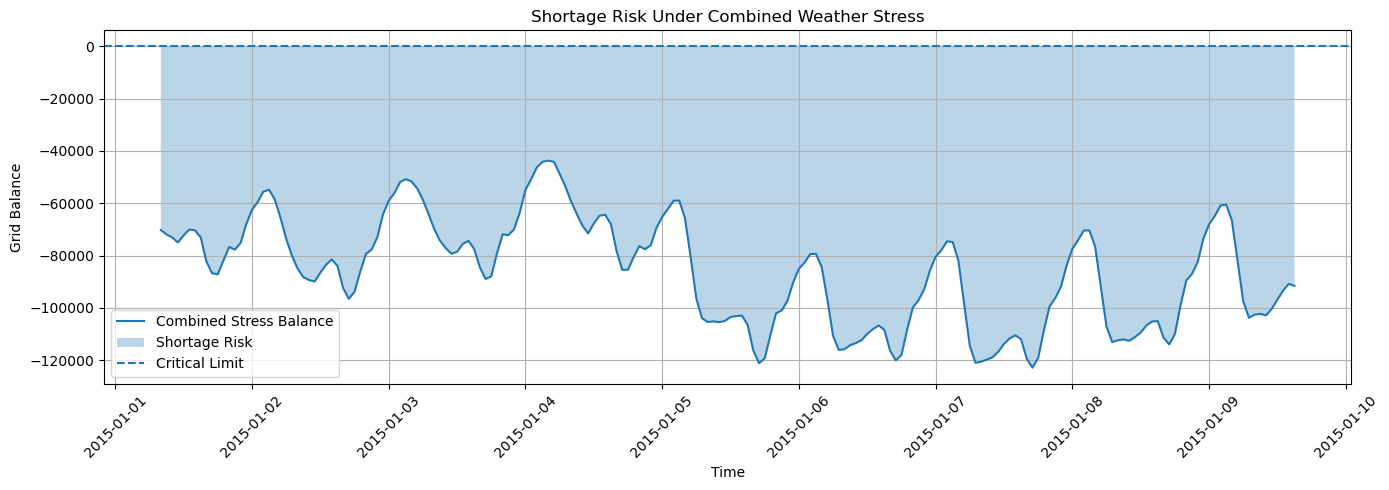

In [13]:
n = 200
plot_df = scenario_df.iloc[:n]

plt.figure(figsize=(14, 5))
plt.plot(plot_df.index, plot_df["stress_balance"], label="Combined Stress Balance")

plt.fill_between(
    plot_df.index,
    plot_df["stress_balance"],
    0,
    where=(plot_df["stress_balance"] < 0),
    alpha=0.3,
    label="Shortage Risk"
)

plt.axhline(0, linestyle="--", label="Critical Limit")

plt.title("Shortage Risk Under Combined Weather Stress")
plt.xlabel("Time")
plt.ylabel("Grid Balance")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

`Key observations`

All scenarios are below zero → demand exceeds generation

The baseline is already negative → system is under stress

The solar drop slightly worsens the situation

The wind drop has a stronger impact than solar

The cold wave (higher demand) pushes balance further down

The combined stress is the worst-case scenario

`Interpretation`

The combined stress scenario consistently produces the lowest grid balance values, indicating that simultaneous reductions in renewable generation and increases in demand significantly worsen system conditions.

In [14]:
print(df.columns)

Index(['cet_cest_timestamp', 'BE_load_actual_entsoe_transparency',
       'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual',
       'BE_wind_generation_actual', 'BE_wind_offshore_generation_actual',
       'BE_wind_onshore_generation_actual',
       'DE_load_actual_entsoe_transparency',
       'DE_load_forecast_entsoe_transparency', 'DE_solar_capacity',
       'DE_solar_generation_actual', 'DE_solar_profile', 'DE_wind_capacity',
       'DE_wind_generation_actual', 'DE_wind_profile',
       'DE_wind_offshore_capacity', 'DE_wind_offshore_generation_actual',
       'DE_wind_offshore_profile', 'DE_wind_onshore_capacity',
       'DE_wind_onshore_generation_actual', 'DE_wind_onshore_profile',
       'FR_load_actual_entsoe_transparency',
       'FR_load_forecast_entsoe_transparency', 'FR_solar_generation_actual',
       'FR_wind_onshore_generation_actual'],
      dtype='object')


In [28]:
cols = [
    "DE_load_actual_entsoe_transparency",
    "FR_load_actual_entsoe_transparency",
    "BE_load_actual_entsoe_transparency",

    "DE_wind_generation_actual",
    "DE_solar_generation_actual",

    "FR_solar_generation_actual",
    "FR_wind_onshore_generation_actual",

    "BE_solar_generation_actual",
    "BE_wind_offshore_generation_actual",
    "BE_wind_onshore_generation_actual"
]


In [30]:
df_model = df[cols].copy().dropna()

In [31]:
df_model["total_generation"] = (
    df_model["DE_solar_generation_actual"] +
    df_model["DE_wind_generation_actual"] +
    df_model["FR_solar_generation_actual"] +
    df_model["FR_wind_onshore_generation_actual"] +
    df_model["BE_solar_generation_actual"] +
    df_model["BE_wind_offshore_generation_actual"] +
    df_model["BE_wind_onshore_generation_actual"]
)

`cloudy weather : generation vs demand `

In [ ]:
scenario_df = df_model.copy()

# Base
scenario_df["total_demand"] = (
    scenario_df["DE_load_actual_entsoe_transparency"] +
    scenario_df["FR_load_actual_entsoe_transparency"] +
    scenario_df["BE_load_actual_entsoe_transparency"]
)

scenario_df["total_generation"] = (
    scenario_df["DE_solar_generation_actual"] +
    scenario_df["DE_wind_generation_actual"] +
    scenario_df["FR_solar_generation_actual"] +
    scenario_df["FR_wind_onshore_generation_actual"] +
    scenario_df["BE_solar_generation_actual"] +
    scenario_df["BE_wind_offshore_generation_actual"] +
    scenario_df["BE_wind_onshore_generation_actual"]
)

scenario_df["grid_balance"] = scenario_df["total_generation"] - scenario_df["total_demand"]

# Cloudy weather: solar drops by 50%
scenario_df["cloudy_generation"] = (
    scenario_df["DE_solar_generation_actual"] * 0.5 +
    scenario_df["DE_wind_generation_actual"] +
    scenario_df["FR_solar_generation_actual"] * 0.5 +
    scenario_df["FR_wind_onshore_generation_actual"] +
    scenario_df["BE_solar_generation_actual"] * 0.5 +
    scenario_df["BE_wind_offshore_generation_actual"] +
    scenario_df["BE_wind_onshore_generation_actual"]
)

scenario_df["cloudy_balance"] = (
    scenario_df["cloudy_generation"] - scenario_df["total_demand"]
)

# Low wind: wind drops by 50%
scenario_df["low_wind_generation"] = (
    scenario_df["DE_solar_generation_actual"] +
    scenario_df["DE_wind_generation_actual"] * 0.5 +
    scenario_df["FR_solar_generation_actual"] +
    scenario_df["FR_wind_onshore_generation_actual"] * 0.5 +
    scenario_df["BE_solar_generation_actual"] +
    scenario_df["BE_wind_offshore_generation_actual"] * 0.5 +
    scenario_df["BE_wind_onshore_generation_actual"] * 0.5
)

scenario_df["low_wind_balance"] = (
    scenario_df["low_wind_generation"] - scenario_df["total_demand"]
)



Solar generation was reduced by 50% to simulate cloudy or overcast conditions.

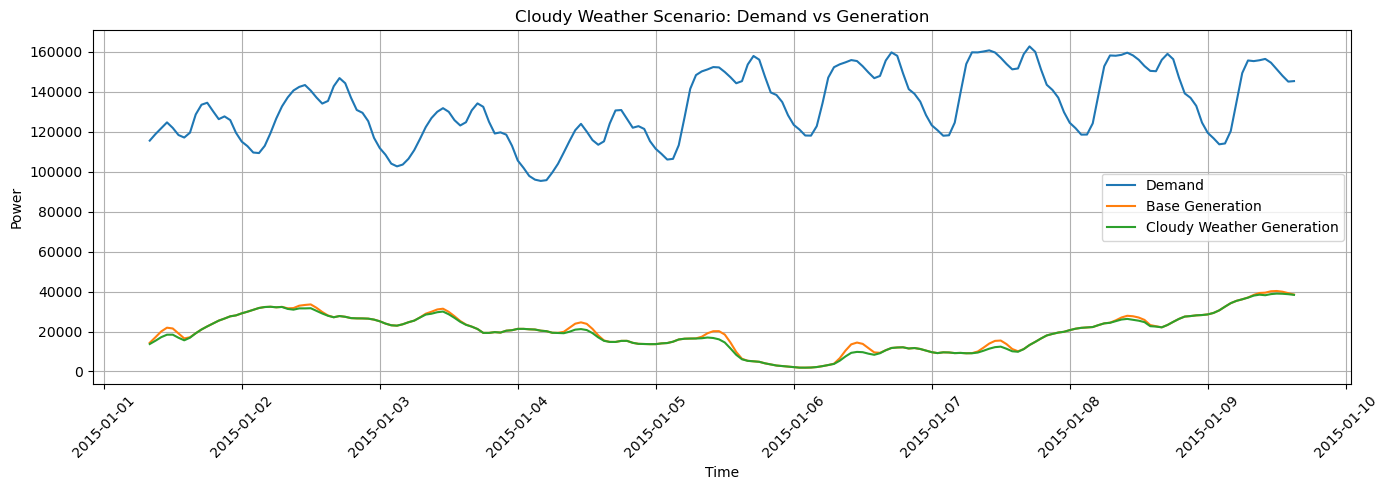

In [37]:
import matplotlib.pyplot as plt

n = 200

plt.figure(figsize=(14, 5))
plt.plot(scenario_df.index[:n], scenario_df["total_demand"].iloc[:n], label="Demand")
plt.plot(scenario_df.index[:n], scenario_df["total_generation"].iloc[:n], label="Base Generation")
plt.plot(scenario_df.index[:n], scenario_df["cloudy_generation"].iloc[:n], label="Cloudy Weather Generation")

plt.title("Cloudy Weather Scenario: Demand vs Generation")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The generation curve decreases compared to the baseline, while demand remains unchanged. This leads to a reduction in the grid balance.

Since wind is a major component of renewable generation, reducing it has a strong impact on total supply. The grid balance decreases more sharply than in the solar scenario.

`cloudy weather: grid balance`

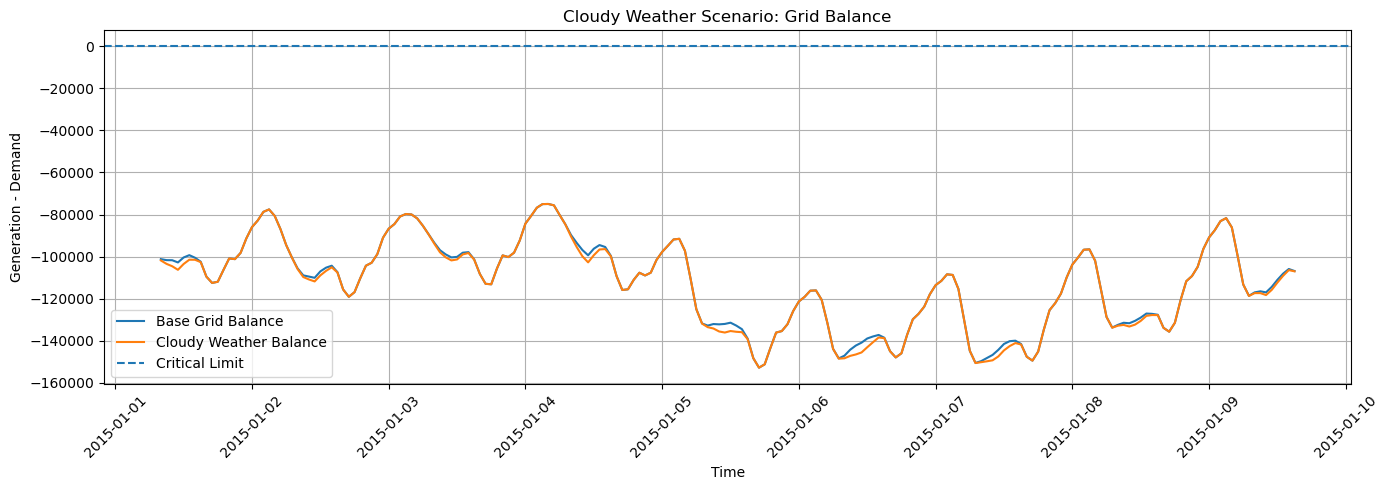

In [38]:
plt.figure(figsize=(14, 5))
plt.plot(scenario_df.index[:n], scenario_df["grid_balance"].iloc[:n], label="Base Grid Balance")
plt.plot(scenario_df.index[:n], scenario_df["cloudy_balance"].iloc[:n], label="Cloudy Weather Balance")

plt.axhline(0, linestyle="--", label="Critical Limit")

plt.title("Cloudy Weather Scenario: Grid Balance")
plt.xlabel("Time")
plt.ylabel("Generation - Demand")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The grid balance curve shifts downward compared to the baseline.
A lower balance means generation is closer to demand, reducing the system’s safety margin.

Solar reductions directly impact grid balance and can lead to critical conditions if demand is high.

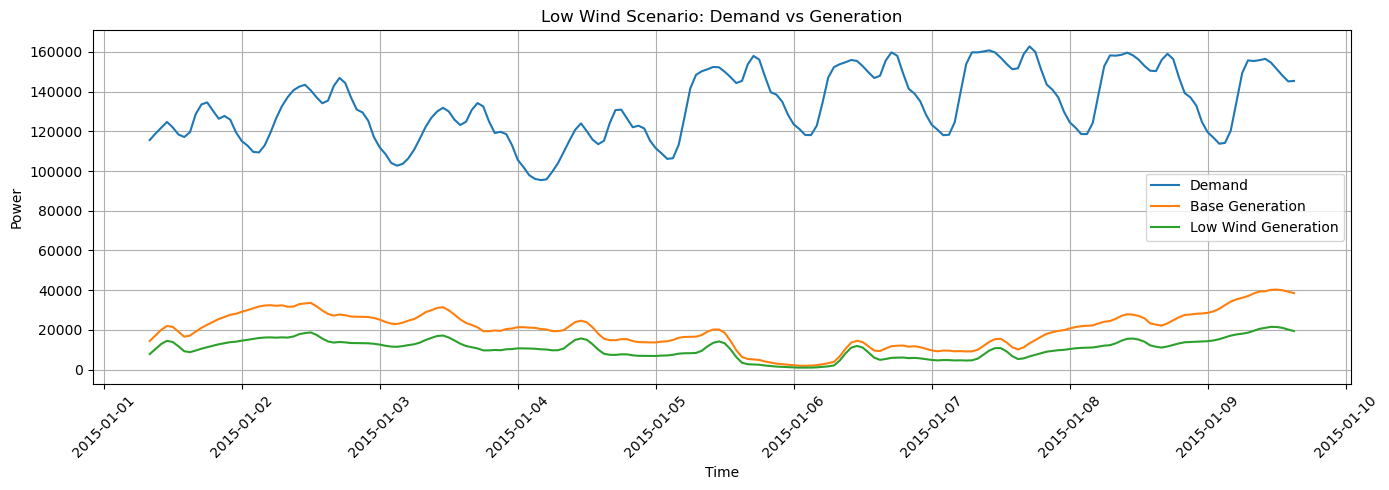

In [39]:
plt.figure(figsize=(14, 5))
plt.plot(scenario_df.index[:n], scenario_df["total_demand"].iloc[:n], label="Demand")
plt.plot(scenario_df.index[:n], scenario_df["total_generation"].iloc[:n], label="Base Generation")
plt.plot(scenario_df.index[:n], scenario_df["low_wind_generation"].iloc[:n], label="Low Wind Generation")

plt.title("Low Wind Scenario: Demand vs Generation")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total generation drops significantly, especially during periods where wind contributes a large share of supply.

Since wind is a major component of renewable generation, reducing it has a strong impact on total supply. The grid balance decreases more sharply than in the solar scenario.

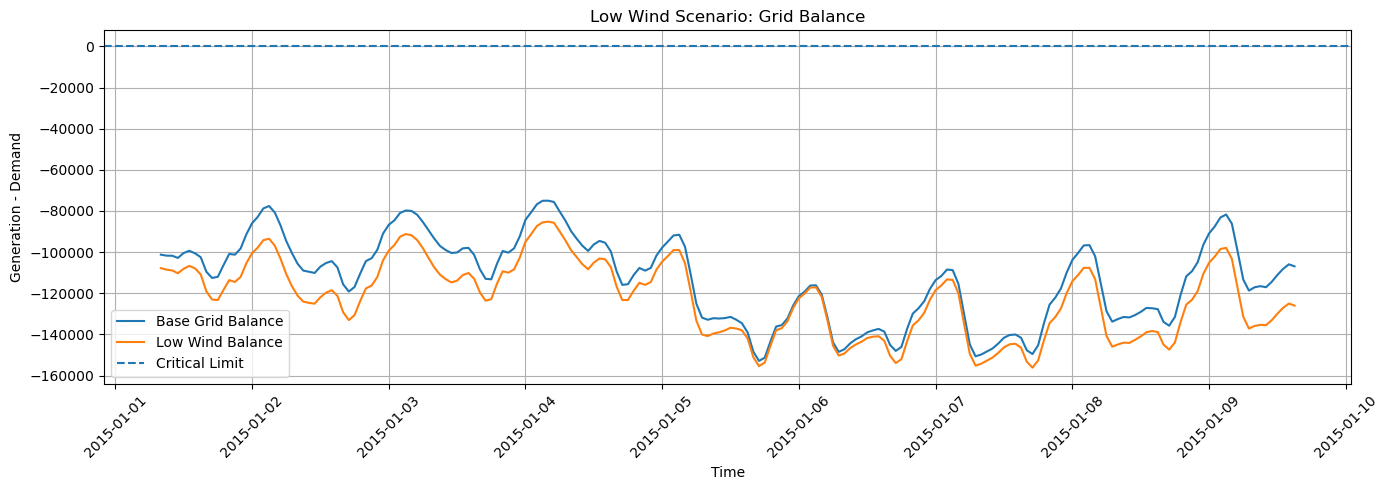

In [40]:
plt.figure(figsize=(14, 5))
plt.plot(scenario_df.index[:n], scenario_df["grid_balance"].iloc[:n], label="Base Grid Balance")
plt.plot(scenario_df.index[:n], scenario_df["low_wind_balance"].iloc[:n], label="Low Wind Balance")

plt.axhline(0, linestyle="--", label="Critical Limit")

plt.title("Low Wind Scenario: Grid Balance")
plt.xlabel("Time")
plt.ylabel("Generation - Demand")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The grid balance drops more sharply than in the cloudy scenario.

Wind contributes more significantly than solar in this system, so its reduction has a larger effect.

Wind variability is a key risk factor for grid stability.

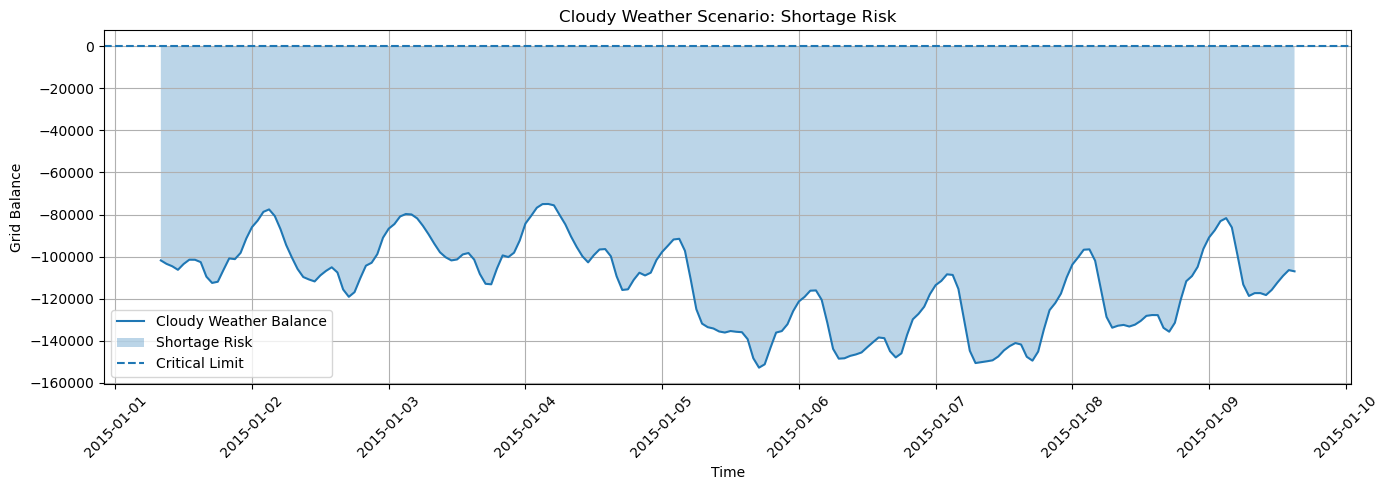

In [41]:
plot_df = scenario_df.iloc[:n]

plt.figure(figsize=(14, 5))
plt.plot(plot_df.index, plot_df["cloudy_balance"], label="Cloudy Weather Balance")

plt.fill_between(
    plot_df.index,
    plot_df["cloudy_balance"],
    0,
    where=(plot_df["cloudy_balance"] < 0),
    alpha=0.3,
    label="Shortage Risk"
)

plt.axhline(0, linestyle="--", label="Critical Limit")

plt.title("Cloudy Weather Scenario: Shortage Risk")
plt.xlabel("Time")
plt.ylabel("Grid Balance")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Blue shaded areas where the balance is below zero.

These are periods where demand exceeds generation.

Cloudy conditions increase the number of shortage periods, highlighting vulnerability to solar variability.

`Conclusions`

Comparing the scenarios shows that reductions in renewable generation, especially wind, significantly impact grid balance. While solar variability affects supply, wind reductions have a larger effect, leading to more frequent and severe shortage conditions.